In [7]:
import cv2
import numpy as py

# we are reading the image here
img = cv2.imread("doggo.jpeg")
#load the image from the file and store in 'img' (color image)

# converting the image to grayscale 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#converts 3 channel (RGB) into 1 channel image (grayscale) 
#we convert a color image into grayscale imag

# converting this to a matrix (grayscale into matrix form)
A = py.array(gray)

print(A.shape)  #printing the dimension of the matrix (m,n) or (rows, column)

(512, 512)


In [8]:
# Apply Singular Value Decomposition
U, S, Vt = py.linalg.svd(A)  #this performs SVD over the image matrix
#returns U,S,Vt

print(U.shape) #prints U (left singular vectors ->2D array) shape
print(S.shape) #print S (singular vectors -> 1D array) shape
print(Vt.shape) #print Vt(right singular vectors-> 2D array) shape

(512, 512)
(512,)
(512, 512)


In [9]:
print("First 10 singular values:")
print(S[:10]) #we print the first ten singular values/ diagonal entries of Sigma
#here we notice that the most important are concentrated in first few singular values

First 10 singular values:
[49478.90310081 12252.61633781  8527.4244133   5726.60881626
  4331.75147004  3625.50063821  3157.41626718  2791.59388959
  2460.19805198  2386.89519506]


In [11]:
import matplotlib.pyplot as plt
k = 50 #we select the top 50 components
#so we will rebuild the image using only 50 most important components

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

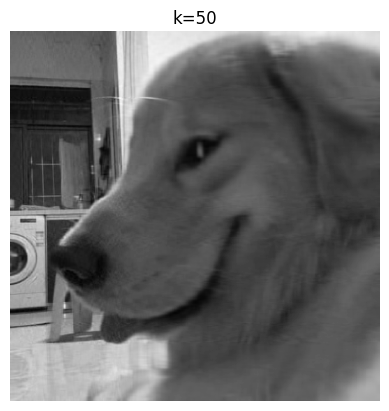

In [12]:
#reduced matrices -> take only the most important values (largest to smallest) derived from eigenvalues AᵀA
U_k = U[:, :k] #take first k columns
S_k = S[:k] #take top k singular values
Vt_k = Vt[:k, :] #take first k rows
#We reconstruct the image using only these reduced matrices

# SVD defines S as the multiplication matrix and these singular values are required for matrix multiplication of compatible dimensions
S_k_diag = py.diag(S_k) #creation of diagonal matrix

# using numpy for matrix multiplication
A_compressed = py.dot(U_k, py.dot(S_k_diag, Vt_k)) 
#reconstruction of matrix by multiplying the reduced matrices : A ≈ Uₖ × Sₖ × Vₖᵀ

plt.imshow(A_compressed, cmap='gray') #shows the compressed image and displays it using grayscale
plt.title(f"k={k}")
plt.axis('off') #we removed the axis for better visualization

#this step performs low-rank matrix approximation, which is the core of SVD-based compression

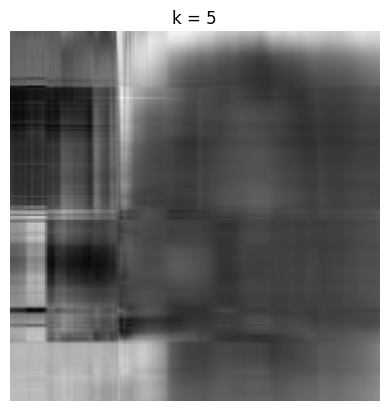

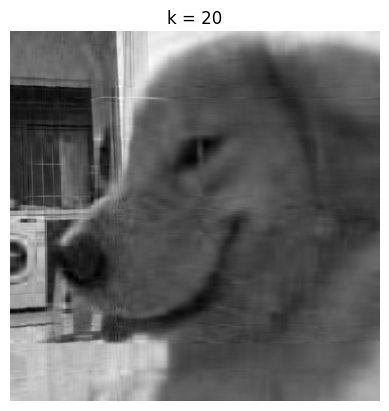

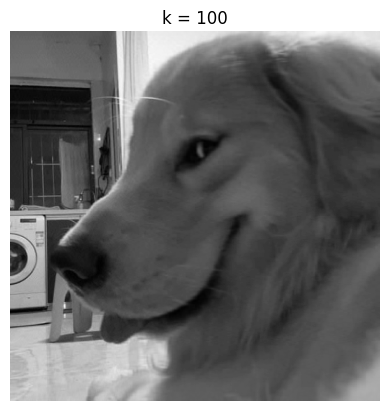

In [15]:
#same thing here as we extract the k components from each of the components
for k in [5, 20, 100]: 
    U_k = U[:, :k] #take first k columns
    S_k = S[:k] #take top k singular values
    Vt_k = Vt[:k, :] #take first k rows
    
    S_k_diag = py.diag(S_k) #converts S (singular values 1D array) into diagonal matrix for matrix multiplication
    A_compressed = py.dot(U_k, py.dot(S_k_diag, Vt_k)) #dot product of all the extracted components to retrieve the compressed image
    
    plt.figure()
    plt.imshow(A_compressed, cmap='gray') #we show the compressed grayscale image
    plt.title(f"k = {k}")
    plt.axis('off')

In [10]:
original_size = A.shape[0] * A.shape[1] #this represent the original image size
#total number of pixel values in image (512 x 512), how much data we store without compression
#choosing k (number of singular components to keep)
#more the k value , better the quality 
#lesser the k, compression and lesser quality (best components remain intact)
for k in [5,10,20,50,100]:
    compressed_size = (512*k) + k + (k*512)
    compression_ratio = original_size / compressed_size
    print(f"Compression Ratio for k={k}:", compression_ratio)

Compression Ratio for k=5: 51.15004878048781
Compression Ratio for k=10: 25.575024390243904
Compression Ratio for k=20: 12.787512195121952
Compression Ratio for k=50: 5.11500487804878
Compression Ratio for k=100: 2.55750243902439
